In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
exact_kernel_df = pd.read_csv("timing/exact_kernels_timing.csv")
label_kernel_df = pd.read_csv("timing/label_kernels_timing.csv")
label_kernel_df['type'] = label_kernel_df['type'].replace('cpu', 'cpu_cutoff')
total_force_timing = pd.concat([exact_kernel_df, label_kernel_df], ignore_index=True)

In [3]:
total_force_timing.head()

,time,n_atom,itr,type
0,2.554145e+07,1000,1,cpu
1,2.554008e+07,1000,2,cpu
2,2.553515e+07,1000,3,cpu
3,2.553823e+07,1000,4,cpu
4,2.698048e+06,1000,1,segmented_traversal


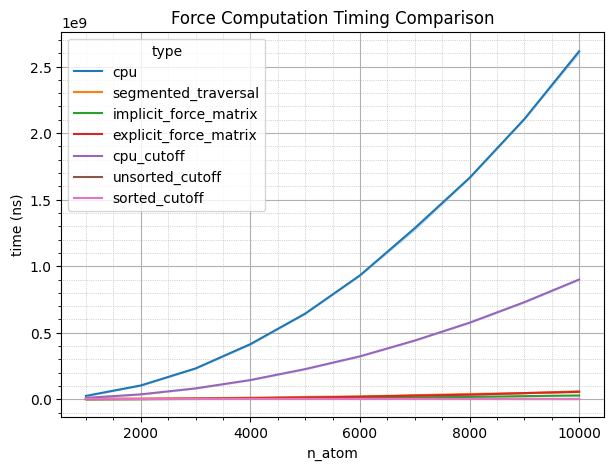

In [12]:
fig, ax = plt.subplots(figsize = (7, 5))
sns.lineplot(total_force_timing, x = "n_atom", y = "time", hue = "type", ax = ax)
ax.set_ylabel("time (ns)")
ax.minorticks_on()
ax.grid()
ax.grid(which='minor', linestyle=':', linewidth=0.5)
ax.set_title("Force Computation Timing Comparison")
fig.savefig("timing/total_kernels_timing_comparison.png", dpi=300)

Text(0.5, 1.0, 'Force Computation Timing Comparison')

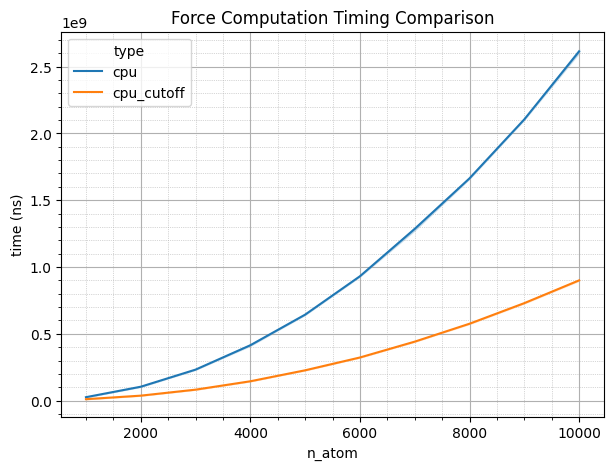

In [15]:
fig, ax = plt.subplots(figsize = (7, 5))
sns.lineplot(data=total_force_timing[total_force_timing["type"].isin(["cpu", "cpu_cutoff"])], x = "n_atom", y = "time", hue = "type", ax = ax)
ax.set_ylabel("time (ns)")
ax.minorticks_on()
ax.grid()
ax.grid(which='minor', linestyle=':', linewidth=0.5)
ax.set_title("Force Computation Timing Comparison")

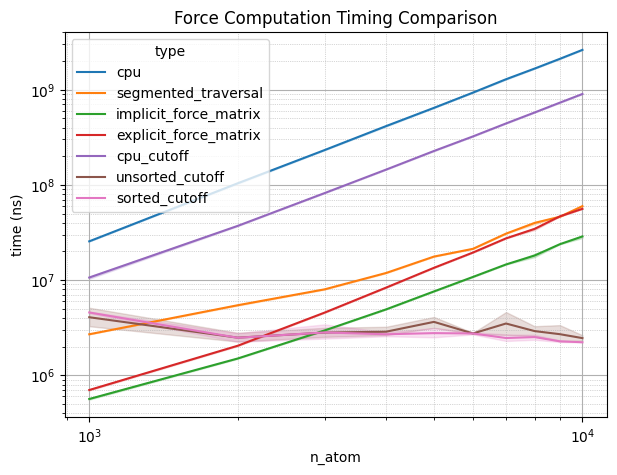

In [11]:
fig, ax = plt.subplots(figsize = (7, 5))
sns.lineplot(data=total_force_timing, x = "n_atom", y = "time", hue = "type", ax = ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("time (ns)")
ax.minorticks_on()
ax.grid()
ax.grid(which='minor', linestyle=':', linewidth=0.5)
ax.set_title("Force Computation Timing Comparison")
fig.savefig("timing/combined_timing.png", dpi=300)

In [12]:
comp_df = total_force_timing.groupby(by = ["n_atom", "type"])['time'].agg("mean").reset_index()
comp_df = comp_df.pivot(index = "n_atom", columns = "type", values = "time").reset_index()
kernel_cols = ['unsorted_cutoff', 'sorted_cutoff', 'cpu_cutoff', 'segmented_traversal', 'implicit_force_matrix', 'explicit_force_matrix']
for col in kernel_cols:
    comp_df[col] = comp_df['cpu'] / comp_df[col]

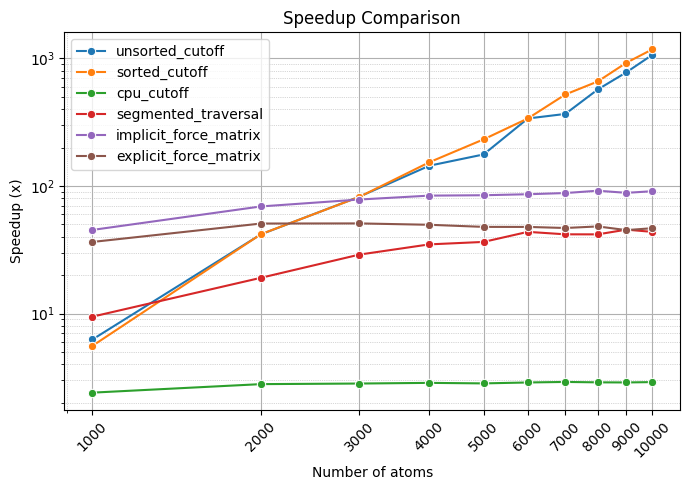

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

for col in kernel_cols:
    sns.lineplot(
        data=comp_df,
        x="n_atom",
        y=col,
        ax=ax,
        label=col,
        marker="o"
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xticks(sorted(comp_df["n_atom"].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.tick_params(axis='x', labelrotation=45)

ax.set_xlabel("Number of atoms")
ax.set_ylabel("Speedup (x)")
ax.set_title("Speedup Comparison")

ax.minorticks_on()
ax.grid(True, which="major")
ax.grid(True, which="minor", linestyle=":", linewidth=0.5)

plt.tight_layout()
plt.show()
fig.savefig("timing/combined_speedup.png", dpi=300)

In [14]:
exact_kernel_df = pd.read_csv("timing/exact_kernels_integration_timing.csv")
label_kernel_df = pd.read_csv("timing/label_kernels_integration_timing.csv")
label_kernel_df['type'] = label_kernel_df['type'].replace('cpu', 'cpu_cutoff')
total_integration_timing = pd.concat([exact_kernel_df, label_kernel_df], ignore_index=True)

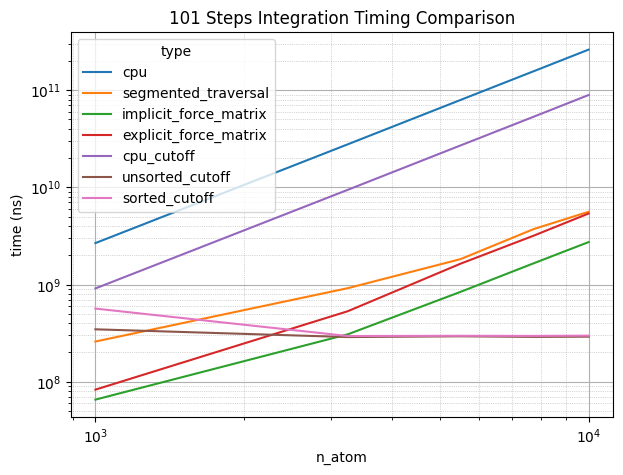

In [16]:
fig, ax = plt.subplots(figsize = (7, 5))
sns.lineplot(total_integration_timing, x = "n_atom", y = "time", hue = "type", ax = ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("time (ns)")
ax.minorticks_on()
ax.grid()
ax.grid(which='minor', linestyle=':', linewidth=0.5)
ax.set_title("101 Steps Integration Timing Comparison")
fig.savefig("timing/combined_101_timing.png", dpi=300)

In [17]:
comp_df = total_integration_timing.groupby(by = ["n_atom", "type"])['time'].agg("mean").reset_index()
comp_df = comp_df.pivot(index = "n_atom", columns = "type", values = "time").reset_index()
kernel_cols = ['unsorted_cutoff', 'sorted_cutoff', 'cpu_cutoff', 'segmented_traversal', 'implicit_force_matrix', 'explicit_force_matrix']
for col in kernel_cols:
    comp_df[col] = comp_df['cpu'] / comp_df[col]

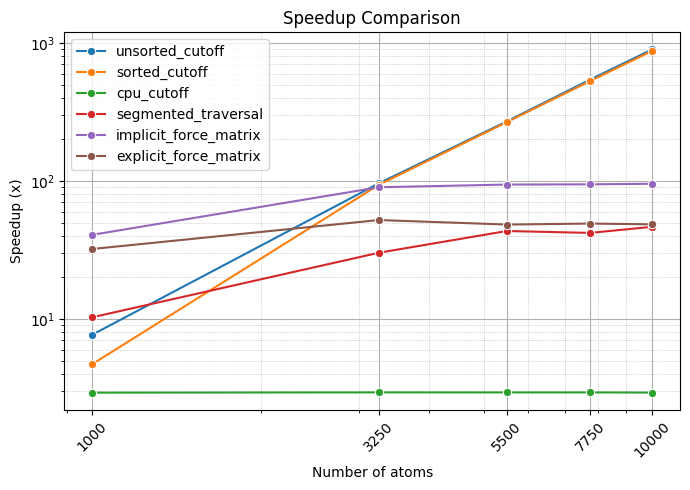

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

for col in kernel_cols:
    sns.lineplot(
        data=comp_df,
        x="n_atom",
        y=col,
        ax=ax,
        label=col,
        marker="o"
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xticks(sorted(comp_df["n_atom"].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.tick_params(axis='x', labelrotation=45)

ax.set_xlabel("Number of atoms")
ax.set_ylabel("Speedup (x)")
ax.set_title("Speedup Comparison")

ax.minorticks_on()
ax.grid(True, which="major")
ax.grid(True, which="minor", linestyle=":", linewidth=0.5)

plt.tight_layout()
plt.show()
fig.savefig("timing/combined_101_speedup.png", dpi=300)

In [36]:
from Forces import initialize_chain_numba
import cupy as cp

In [58]:
import numpy as np
import matplotlib.pyplot as plt

def plot_atoms_local_grid(positions, box_size, cell_size, padding_cells=1):
    positions = np.asarray(positions)

    if positions.shape[0] == 3:
        x, y, z = positions[0], positions[1], positions[2]
    else:
        x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]

    padding = padding_cells * cell_size

    xmin = max(0, x.min() - padding)
    xmax = min(box_size, x.max() + padding)
    ymin = max(0, y.min() - padding)
    ymax = min(box_size, y.max() + padding)
    zmin = max(0, z.min() - padding)
    zmax = min(box_size, z.max() + padding)

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(x, y, z, s=8, alpha=0.7)

    # Draw only grid lines near atoms
    gx = np.arange(np.floor(xmin / cell_size) * cell_size, xmax + cell_size, cell_size)
    gy = np.arange(np.floor(ymin / cell_size) * cell_size, ymax + cell_size, cell_size)
    gz = np.arange(np.floor(zmin / cell_size) * cell_size, zmax + cell_size, cell_size)

    for xx in gx:
        for yy in gy:
            ax.plot([xx, xx], [yy, yy], [zmin, zmax], linewidth=0.4)

    for xx in gx:
        for zz in gz:
            ax.plot([xx, xx], [ymin, ymax], [zz, zz], linewidth=0.4)

    for yy in gy:
        for zz in gz:
            ax.plot([xmin, xmax], [yy, yy], [zz, zz], linewidth=0.4)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    # ax.set_title("Local Atom Distribution with Cell Grid")

    plt.tight_layout()
    plt.show()
    fig.savefig("chain_overview.png", dpi=300)

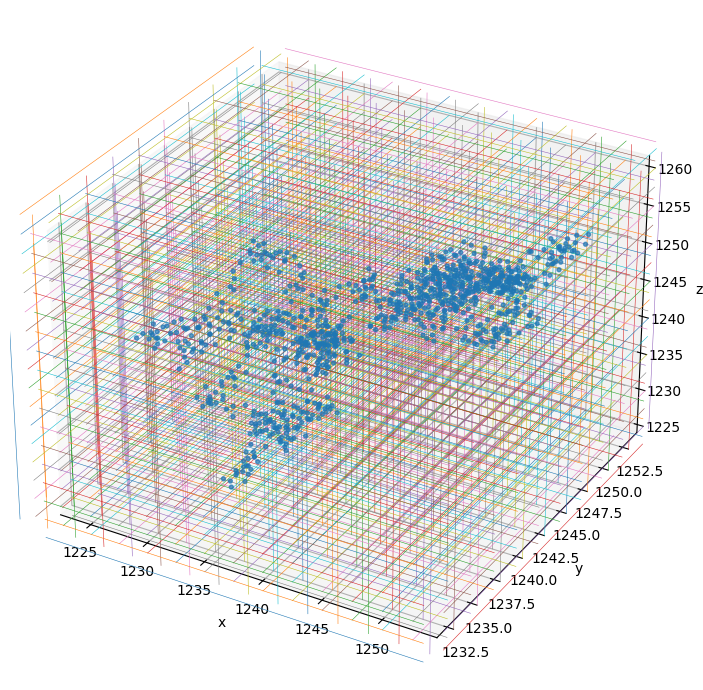

In [59]:
seed = 42
rng_np = np.random.default_rng(seed)
rng_cp = cp.random.default_rng(seed)
chain_lens = np.round(np.linspace(1e3, 1e4, 10)).astype(np.int32)
k = 500
r0 = 1
epsilon_attractive = 0.5
epsilon_repulsive = 1.0
sigma = 1.0

n_atoms = 1000
box_size = n_atoms * r0 * 2.5
cell_size = 2.5
const_params_h = np.array([box_size, k, r0, epsilon_attractive, epsilon_repulsive, sigma])
const_params_d = cp.array(const_params_h)
pos = initialize_chain_numba(n_atoms, box_size, r0, rng_np, dtype = np.float64)

plot_atoms_local_grid(
    positions=pos,
    box_size=box_size,
    cell_size=cell_size
)

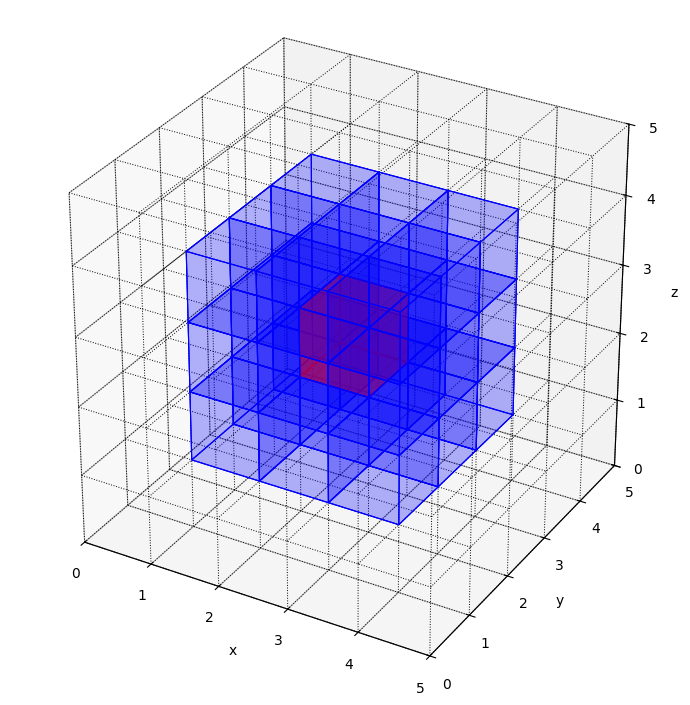

In [56]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def draw_cell(ax, x, y, z, color, alpha=0.18):
    verts = [
        [(x,y,z), (x+1,y,z), (x+1,y+1,z), (x,y+1,z)],
        [(x,y,z+1), (x+1,y,z+1), (x+1,y+1,z+1), (x,y+1,z+1)],
        [(x,y,z), (x+1,y,z), (x+1,y,z+1), (x,y,z+1)],
        [(x,y+1,z), (x+1,y+1,z), (x+1,y+1,z+1), (x,y+1,z+1)],
        [(x,y,z), (x,y+1,z), (x,y+1,z+1), (x,y,z+1)],
        [(x+1,y,z), (x+1,y+1,z), (x+1,y+1,z+1), (x+1,y,z+1)],
    ]
    ax.add_collection3d(
        Poly3DCollection(
            verts,
            facecolors=color,
            edgecolors=color,
            linewidths=0.8,
            alpha=alpha
        )
    )

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw 5 x 5 x 5 outer grid with dotted lines
for i in range(6):
    for j in range(6):
        ax.plot([0, 5], [i, i], [j, j], "k:", linewidth=0.7)
        ax.plot([i, i], [0, 5], [j, j], "k:", linewidth=0.7)
        ax.plot([i, i], [j, j], [0, 5], "k:", linewidth=0.7)

# Inner 3 x 3 x 3 region is from cells 1 to 3 in each direction
# Outer cells of inner 3 x 3 x 3 are blue; center cell is red
for x in range(1, 4):
    for y in range(1, 4):
        for z in range(1, 4):
            if x == 2 and y == 2 and z == 2:
                draw_cell(ax, x, y, z, color="red", alpha=0.45)
            else:
                draw_cell(ax, x, y, z, color="blue", alpha=0.16)

ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_zlim(0, 5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_box_aspect([1, 1, 1])
plt.tight_layout()
plt.show()
fig.savefig("cutoff_illustration.png", dpi=300)